# ExoMetrix Training Notebook
## Gait Analysis ML Pipeline for Rehabilitation Assistance
---
This notebook documents the complete training pipeline for the ExoMetrix gait analysis system. It covers:
- Data loading and signal extraction from MATLAB biomechanics files
- Feature engineering (14 statistical features per window)
- Label derivation from file system paths
- Two-stage model training: Anomaly detection + Activity/Intention classification
- Training logs and metrics for professor review
- Inference demo with model runtime

## Overview and Known Limitations

This notebook builds the ExoMetrix gait model end-to-end: discover data, extract knee-angle signals, calibrate angles, compute features, train models, evaluate, and export artifacts for the runtime API.

**Pipeline summary**
- Data: AB06-AB08 biomechanics sessions (gon angle MAT files).
- Models: IsolationForest for anomaly detection + RandomForest for activity/intention.
- Outputs: `gait_model.joblib` and `gait_model_meta.json` in `backend/models/`.

**Known limitations (tracked and partially addressed here)**
- Labels are derived from folder names and filenames (not manual annotation).
- Velocity features were previously unnormalized; now normalized by downsampling stride.
- Single split accuracy can be optimistic; cross-validation is added for robustness.
- Training data is limited to able-bodied subjects (no patient gait yet).


## 1. Setup & Imports

In [2]:
import sys
import subprocess
import warnings
import json
import time
from pathlib import Path
from collections import Counter
from typing import Iterable, List, Tuple

warnings.filterwarnings("ignore")

# Install missing dependencies only when needed.
def ensure_packages(package_map):
    missing = []
    for import_name, pip_name in package_map.items():
        try:
            __import__(import_name)
        except Exception:
            missing.append(pip_name)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])

ensure_packages({
    "numpy": "numpy",
    "scipy": "scipy",
    "h5py": "h5py",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
})

import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None

PROJECT_ROOT = Path(r"C:\mahmoud\college")
DATA_ROOT = PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / "backend" / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_MODEL = OUTPUT_DIR / "gait_model.joblib"
OUTPUT_META = OUTPUT_DIR / "gait_model_meta.json"

FEATURE_NAMES = [
    "mean_angle", "std_angle", "min_angle", "max_angle",
    "range_angle", "median_angle", "p10_angle", "p90_angle",
    "mean_abs_velocity", "std_velocity", "max_velocity", "min_velocity",
    "energy", "peak_density",
]

RUN_ID = time.strftime("%Y%m%d_%H%M%S")
LOG_FILE = OUTPUT_DIR / f"training_log_{RUN_ID}.txt"


def print_section(title: str, width: int = 70) -> None:
    line = "=" * width
    print(f"\n{line}\n{title}\n{line}")


def safe_percentile(values: np.ndarray, p: float) -> float:
    values = values[np.isfinite(values)]
    if values.size == 0:
        return float("nan")
    return float(np.percentile(values, p))


def describe_vector(values: np.ndarray, label: str) -> None:
    values = values[np.isfinite(values)]
    print(
        f"{label}: n={values.size:,}, min={values.min():.2f}, max={values.max():.2f}, "
        f"mean={values.mean():.2f}, std={values.std():.2f}, p01={safe_percentile(values, 1):.2f}, "
        f"p99={safe_percentile(values, 99):.2f}"
    )


def train_classifier(
    X: np.ndarray,
    labels: List[str],
    name: str,
    n_estimators: int = 350,
    random_state: int = 42,
    test_size: float = 0.2,
) -> Tuple[RandomForestClassifier, dict]:
    class_counts = Counter(labels)
    min_count = min(class_counts.values()) if class_counts else 0
    use_validation = X.shape[0] >= 30 and min_count >= 2

    if use_validation:
        X_train, X_val, y_train, y_val = train_test_split(
            X, labels, test_size=test_size, random_state=random_state, stratify=labels
        )
    else:
        X_train, X_val, y_train, y_val = X, None, labels, None

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)

    print(f"Trained {name} classifier with {len(class_counts)} classes and class counts: {class_counts}")
    result = {
        "name": name,
        "use_validation": use_validation,
        "class_counts": class_counts,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
    }

    if use_validation:
        y_pred = clf.predict(X_val)
        result["y_pred"] = y_pred
        result["accuracy"] = accuracy_score(y_val, y_pred)
        print(f"Validation accuracy for {name}: {result['accuracy']:.4f}")
    return clf, result


print_section("SETUP")
print(f"Data root: {DATA_ROOT}")
print(f"Output model: {OUTPUT_MODEL}")
print(f"Features: {len(FEATURE_NAMES)}")
print(f"Log file: {LOG_FILE.name}")


SETUP
Data root: C:\mahmoud\college
Output model: C:\mahmoud\college\backend\models\gait_model.joblib
Features: 14
Log file: training_log_20260428_153909.txt


## 2. Data Discovery

In [3]:
def discover_subjects(data_root: Path, subject_glob: str = "AB*") -> List[Path]:
    """Discover subject folders from dataset root."""
    if (data_root / "osimxml").exists():
        return [data_root]

    discovered = sorted(
        path for path in data_root.glob(subject_glob)
        if path.is_dir() and (path / "osimxml").exists()
    )
    if discovered:
        return discovered

    discovered = sorted(
        path for path in data_root.glob(subject_glob)
        if path.is_dir() and list(path.rglob("gon/*.mat"))
    )
    if discovered:
        return discovered

    return [data_root]


subject_roots = discover_subjects(DATA_ROOT)
print_section("STEP 2: DATA DISCOVERY")

summary_rows = []
total_files = 0
for subj in subject_roots:
    date_folders = [
        d.name for d in subj.iterdir()
        if d.is_dir() and d.name.startswith("10")
    ]
    locomotion_types = set()
    for loc in ["levelground", "ramp", "stair", "treadmill"]:
        if (subj / loc / "gon").exists():
            locomotion_types.add(loc)
        for date_folder in date_folders:
            if (subj / date_folder / loc / "gon").exists():
                locomotion_types.add(loc)

    mat_files = list(subj.rglob("gon/*.mat"))
    total_files += len(mat_files)
    summary_rows.append(
        (subj.name, date_folders or ["(none)"], sorted(locomotion_types) or ["(none)"], len(mat_files))
    )

for name, dates, locomotion, count in summary_rows:
    print(f"- {name}: dates={dates}, locomotion={locomotion}, files={count}")

print(f"Subjects: {len(subject_roots)} | Total MAT files: {total_files}")


STEP 2: DATA DISCOVERY
- AB06: dates=['10_09_18'], locomotion=['levelground', 'ramp', 'stair', 'treadmill'], files=143
- AB07: dates=['10_14_18'], locomotion=['levelground', 'ramp', 'stair', 'treadmill'], files=153
- AB08: dates=['10_21_2018'], locomotion=['levelground', 'ramp', 'stair', 'treadmill'], files=138
Subjects: 3 | Total MAT files: 434


## 3. Signal Extraction Functions

In [4]:
def load_mat_file(path: Path):
    if loadmat is not None:
        try:
            return loadmat(path, squeeze_me=True, struct_as_record=False)
        except Exception:
            pass
    import h5py
    result = {}
    with h5py.File(path, "r") as f:
        for key in f.keys():
            result[key] = np.array(f[key])
    return result


def iter_mat_values(node) -> Iterable[np.ndarray]:
    if isinstance(node, np.ndarray):
        if node.dtype == object:
            for item in node.flat:
                yield from iter_mat_values(item)
        else:
            yield node
        return
    if hasattr(node, "_fieldnames"):
        for name in getattr(node, "_fieldnames", []):
            yield from iter_mat_values(getattr(node, name))
        return
    if isinstance(node, dict):
        for key, value in node.items():
            if str(key).startswith("__"):
                continue
            yield from iter_mat_values(value)
        return
    if isinstance(node, (list, tuple)):
        for item in node:
            yield from iter_mat_values(item)


def extract_from_function_workspace(mat_obj) -> np.ndarray | None:
    workspace = mat_obj.get("__function_workspace__")
    if workspace is None:
        return None
    raw = np.asarray(workspace, dtype=np.uint8).ravel()
    if raw.size < 8 * 100:
        return None
    best_signal = None
    best_score = float("-inf")
    for offset in range(8):
        n = (raw.size - offset) // 8
        if n < 100:
            continue
        chunk = raw[offset : offset + n * 8]
        values = np.frombuffer(chunk.tobytes(), dtype="<f8")
        values = values[np.isfinite(values)]
        values = values[(values >= -220.0) & (values <= 220.0)]
        if values.size < 100:
            continue
        p1 = float(np.percentile(values, 1))
        p99 = float(np.percentile(values, 99))
        dynamic = p99 - p1
        spread = float(np.std(values))
        score = values.size + dynamic * 50.0 + spread * 25.0
        if score > best_score:
            best_score = score
            best_signal = values.copy()
    return best_signal


def choose_signal(arrays: List[np.ndarray]) -> np.ndarray | None:
    candidates = []
    for arr in arrays:
        if not np.issubdtype(arr.dtype, np.number):
            continue
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size < 40:
            continue
        if arr.ndim == 1:
            series = arr
        else:
            flattened = arr.reshape(arr.shape[0], -1) if arr.shape[0] > 1 else arr.reshape(-1, 1)
            stds = np.nanstd(flattened, axis=0)
            idx = int(np.argmax(stds))
            series = flattened[:, idx]
        if series.size < 40:
            continue
        variance = float(np.nanvar(series))
        dynamic = float(np.nanmax(series) - np.nanmin(series))
        within_angle_like = np.mean((series >= -200) & (series <= 220))
        score = variance + dynamic * 0.1 + within_angle_like * 10
        candidates.append((score, series))
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0], reverse=True)
    print(f"Best signal score for {name}: {candidates[0][0]:.4f}")
    return candidates[0][1]


def downsample_signal(signal: np.ndarray, max_per_file: int | None) -> Tuple[np.ndarray, int]:
    if max_per_file is None or signal.size <= max_per_file:
        return signal, 1
    step = max(1, signal.size // max_per_file)
    return signal[::step][:max_per_file], step


def extract_best_signal(mat_obj, max_per_file: int | None = None, return_stride: bool = False):
    arrays = list(iter_mat_values(mat_obj))
    signal = choose_signal(arrays)
    if signal is None:
        signal = extract_from_function_workspace(mat_obj)
    if signal is None:
        return (None, 1) if return_stride else None
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)] #cleaning
    signal = signal[(signal >= -220.0) & (signal <= 220.0)]
    if signal.size < 40:
        return (None, 1) if return_stride else None

    signal, stride = downsample_signal(signal, max_per_file)
    result = signal.astype(float)
    return (result, stride) if return_stride else result


print("Signal extraction helpers ready.")

Signal extraction helpers ready.


## 4. Calibration

In [5]:
def calibrate_to_app_angle_range(raw_angles: np.ndarray) -> np.ndarray:
    p1 = float(np.percentile(raw_angles, 1))
    p99 = float(np.percentile(raw_angles, 99))
    if abs(p99 - p1) < 1e-6:
        return np.clip(raw_angles, 0.0, 180.0)
    target_low, target_high = 5.0, 120.0
    scale = (target_high - target_low) / (p99 - p1)
    shift = target_low - scale * p1
    calibrated = raw_angles * scale + shift
    return np.clip(calibrated, 0.0, 180.0)


def collect_all_angles(subject_roots: List[Path], max_per_file: int = 2000) -> np.ndarray:
    all_angles = []
    for subj in subject_roots:
        files = sorted(subj.rglob("gon/*.mat"))
        for mat_path in files:
            try:
                mat_obj = load_mat_file(mat_path)
                signal = extract_best_signal(mat_obj, max_per_file=max_per_file)
                if signal is not None:
                    all_angles.append(signal.astype(float))
            except Exception as exc:
                print(f"[WARN] Skipping {mat_path.name}: {exc}")
    if not all_angles:
        raise RuntimeError("No valid signals extracted.")
    merged = np.concatenate(all_angles, axis=0)
    merged = merged[np.isfinite(merged)]
    return merged


print_section("STEP 4: CALIBRATION")
raw_angles_all = collect_all_angles(subject_roots)

print("Raw angle statistics")
describe_vector(raw_angles_all, "Raw angles")

calibrated_angles = calibrate_to_app_angle_range(raw_angles_all)
print("Calibration: map p01 -> 5, p99 -> 120, clip to [0, 180]")
print("Calibrated angle statistics")
describe_vector(calibrated_angles, "Calibrated angles")


STEP 4: CALIBRATION
Raw angle statistics
Raw angles: n=868,000, min=-112.78, max=158.68, mean=6.68, std=31.77, p01=-72.34, p99=112.65
Calibration: map p01 -> 5, p99 -> 120, clip to [0, 180]
Calibrated angle statistics
Calibrated angles: n=868,000, min=0.00, max=148.61, mean=54.16, std=19.65, p01=5.00, p99=120.00


## 5. Feature Engineering

### Feature Description Table

Each MAT file is treated as one signal window. We extract 14 statistical features:

| # | Feature | Purpose |
|---|---------|---------|
| 1-4 | mean, std, min, max | Basic angle statistics |
| 5 | range | Total arc of motion |
| 6-8 | median, p10, p90 | Robust percentiles |
| 9-12 | velocity stats | Mean/std/max/min of normalized velocity |
| 13 | energy | Signal energy (variance) |
| 14 | peak_density | Approximate step frequency |

**Velocity normalization update**
- `np.diff()` is divided by the downsampling stride, so velocity features have a consistent scale across files.

In [6]:
def count_peaks(values: np.ndarray) -> int:
    if values.size < 3:
        return 0
    threshold = float(np.mean(values) + 0.25 * np.std(values))
    peaks = 0
    for i in range(1, values.size - 1):
        if values[i] > values[i - 1] and values[i] >= values[i + 1] and values[i] > threshold:
            peaks += 1
    return peaks


def extract_window_features(values: np.ndarray, velocity_stride: int = 1) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)] #cleaning the data
    if values.size < 6:
        pad = np.full(6 - values.size, values[-1] if values.size else 0.0) #use last value if signal is small
        values = np.concatenate([values, pad], axis=0)
    velocity = np.diff(values)
    if velocity.size == 0:
        velocity = np.array([0.0], dtype=float)
    velocity = velocity / max(int(velocity_stride), 1)

    peaks = count_peaks(values)
    peak_density = float(peaks / max(values.size, 1))

    feature_vector = np.array([
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values)),
        float(np.max(values) - np.min(values)),
        float(np.median(values)),
        float(np.percentile(values, 10)),
        float(np.percentile(values, 90)),
        float(np.mean(np.abs(velocity))),
        float(np.std(velocity)),
        float(np.max(velocity)),
        float(np.min(velocity)),
        float(np.mean(np.square(values - np.mean(values)))),
        peak_density,
    ], dtype=float)
    return feature_vector


def collect_labeled_features(subject_roots: List[Path], max_per_file: int = 2000):
    feature_rows = []
    activity_labels = []
    intention_labels = []
    source_files = []
    stride_values = []
    for subj in subject_roots:
        files = sorted(subj.rglob("gon/*.mat"))
        for mat_path in files:
            try:
                mat_obj = load_mat_file(mat_path)
                signal, stride = extract_best_signal(mat_obj, max_per_file=max_per_file, return_stride=True)
                if signal is None:
                    continue
                stride_values.append(stride)

                calibrated = calibrate_to_app_angle_range(signal)
                features = extract_window_features(calibrated, velocity_stride=stride)
                feature_rows.append(features)
                source_files.append(mat_path)

                activity = None
                for parent in mat_path.parents:
                    if parent.name.lower() in ["levelground", "ramp", "stair", "treadmill"]:
                        activity = parent.name.lower()
                        break
                if activity is None:
                    activity = mat_path.parents[1].name.lower()

                stem = mat_path.stem.lower()
                if activity == "levelground":
                    activity_label = "levelground"
                    intention_label = "running" if "_fast_" in stem else "walking"
                elif activity == "stair":
                    activity_label = "stair"
                    intention_label = "upstairs"
                elif activity == "ramp":
                    activity_label = "ramp"
                    intention_label = "ramp_up"
                elif activity == "treadmill":
                    activity_label = "treadmill"
                    intention_label = "walking"
                else:
                    activity_label = "unknown"
                    intention_label = "walking"

                activity_labels.append(activity_label)
                intention_labels.append(intention_label)
            except Exception as exc:
                print(f"[WARN] Skipping {mat_path.name}: {exc}")
    return feature_rows, activity_labels, intention_labels, source_files, stride_values


print_section("STEP 5: FEATURE ENGINEERING")
feature_rows, activity_labels, intention_labels, source_files, stride_values = collect_labeled_features(subject_roots)

X = np.vstack(feature_rows).astype(float)
print(f"Feature matrix: {X.shape[0]} windows x {X.shape[1]} features")

if stride_values:
    stride_array = np.array(stride_values, dtype=float)
    print(
        f"Downsampling stride: mean={stride_array.mean():.2f}, "
        f"median={np.median(stride_array):.2f}, min={stride_array.min():.0f}, max={stride_array.max():.0f}"
    )

print("Per-feature statistics")
for i, name in enumerate(FEATURE_NAMES):
    col = X[:, i]
    finite = col[np.isfinite(col)]
    print(
        f"{i + 1:2d}. {name:18s} "
        f"min={finite.min():8.2f}, max={finite.max():8.2f}, mean={finite.mean():8.2f}, std={finite.std():8.2f}"
    )


STEP 5: FEATURE ENGINEERING
Feature matrix: 434 windows x 14 features
Downsampling stride: mean=73.63, median=49.00, min=36, max=436
Per-feature statistics
 1. mean_angle         min=   42.89, max=   90.67, mean=   70.46, std=   10.86
 2. std_angle          min=   16.52, max=   30.12, mean=   23.50, std=    2.96
 3. min_angle          min=    0.00, max=    2.44, mean=    0.06, std=    0.31
 4. max_angle          min=  120.46, max=  138.71, mean=  123.67, std=    4.32
 5. range_angle        min=  119.90, max=  138.71, mean=  123.62, std=    4.31
 6. median_angle       min=   36.28, max=   90.54, mean=   66.32, std=   13.75
 7. p10_angle          min=   27.70, max=   76.06, mean=   49.37, std=   11.01
 8. p90_angle          min=   75.78, max=  115.85, mean=  108.29, std=    9.24
 9. mean_abs_velocity  min=    0.01, max=    0.07, mean=    0.04, std=    0.01
10. std_velocity       min=    0.02, max=    0.14, mean=    0.07, std=    0.02
11. max_velocity       min=    0.06, max=    1.69, me

## 6. Label Distribution Analysis

### Labeling Heuristics and Known Gaps

Labels come from file paths (not manual annotation). Heuristics:
- **Levelground**: filename contains `_fast_` -> running, else walking
- **Stair**: upstairs (descent not labeled in this dataset)
- **Ramp**: ramp_up (descent not labeled in this dataset)
- **Treadmill**: walking (speed not labeled)

**Impact**: direction is ambiguous for stair/ramp, and fast-walk vs run relies on filename.

In [7]:
activity_counts = Counter(activity_labels)
intention_counts = Counter(intention_labels)

print_section("STEP 6: LABEL DISTRIBUTION")


def print_counts(counts: Counter, title: str) -> None:
    total = sum(counts.values())
    print(title)
    for label, count in sorted(counts.items()):
        pct = 100 * count / max(total, 1)
        print(f"  {label:12s}: {count:4d} ({pct:5.1f}%)")


print_counts(activity_counts, "Activity labels")
print_counts(intention_counts, "Intention labels")

print(f"Total windows: {len(activity_labels)}")


STEP 6: LABEL DISTRIBUTION
Activity labels
  levelground :   97 ( 22.4%)
  ramp        :  193 ( 44.5%)
  stair       :  120 ( 27.6%)
  treadmill   :   24 (  5.5%)
Intention labels
  ramp_up     :  193 ( 44.5%)
  running     :   31 (  7.1%)
  upstairs    :  120 ( 27.6%)
  walking     :   90 ( 20.7%)
Total windows: 434


## 7. Model Training - Anomaly Detector (IsolationForest)

### IsolationForest (Short Explanation)

IsolationForest is unsupervised and flags outliers by how quickly points are isolated in random trees. We use:
- `n_estimators=300`, `contamination=0.08`, `random_state=42`
- RobustScaler to reduce the impact of sensor spikes

In [8]:
print_section("STEP 7: ANOMALY DETECTOR (IsolationForest)")

X_anomaly = calibrated_angles.reshape(-1, 1)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_anomaly)

anomaly_model = IsolationForest(
    n_estimators=300,
    contamination=0.08,
    random_state=42,
    n_jobs=-1,
)
anomaly_model.fit(X_scaled)

scores = anomaly_model.decision_function(X_scaled)
score_stats = {
    "min": float(scores.min()),
    "max": float(scores.max()),
    "mean": float(scores.mean()),
    "std": float(scores.std()),
    "p01": safe_percentile(scores, 1),
    "p05": safe_percentile(scores, 5),
    "p50": safe_percentile(scores, 50),
    "p95": safe_percentile(scores, 95),
    "p99": safe_percentile(scores, 99),
}

print(
    "Score stats: "
    f"min={score_stats['min']:.4f}, max={score_stats['max']:.4f}, "
    f"mean={score_stats['mean']:.4f}, std={score_stats['std']:.4f}"
)
print(
    "Percentiles: "
    f"p01={score_stats['p01']:.4f}, p05={score_stats['p05']:.4f}, "
    f"p50={score_stats['p50']:.4f}, p95={score_stats['p95']:.4f}, p99={score_stats['p99']:.4f}"
)

predictions = anomaly_model.predict(X_scaled)
n_anomalies = int(np.sum(predictions == -1))
n_normal = int(np.sum(predictions == 1))
print(
    f"Flagged anomalies: {n_anomalies:,} "
    f"({100 * n_anomalies / len(predictions):.1f}%), "
    f"normal: {n_normal:,}"
)



STEP 7: ANOMALY DETECTOR (IsolationForest)


Score stats: min=-0.1713, max=0.2208, mean=0.1461, std=0.0838
Percentiles: p01=-0.1129, p05=-0.0273, p50=0.1778, p95=0.2182, p99=0.2197
Flagged anomalies: 69,430 (8.0%), normal: 798,570


## 8. Model Training - Classifiers

We train RandomForest classifiers for activity and intention. We report a holdout split plus StratifiedKFold cross-validation for activity.

### Validation Notes and Label Correlation

- A single 80/20 split can be optimistic; we add StratifiedKFold cross-validation for a more stable estimate.
- Activity and intention labels are tightly correlated in this dataset:
  - `stair` -> `upstairs`
  - `ramp` -> `ramp_up`
  - `treadmill` -> `walking`
  - `levelground` -> `walking` or `running` if `_fast_` in filename

Because the label mapping is almost 1:1, both classifiers tend to show similar accuracy in this dataset.

In [9]:
print_section("STEP 8: CLASSIFIERS")

activity_clf, activity_eval = train_classifier(X, activity_labels, name="activity")
intention_clf, intention_eval = train_classifier(X, intention_labels, name="intention")

activity_accuracy = activity_eval.get("accuracy")
intention_accuracy = intention_eval.get("accuracy")

if activity_eval["use_validation"]:
    print(f"Activity accuracy: {activity_accuracy:.1%}")
else:
    print("Activity accuracy: validation skipped")

if intention_eval["use_validation"]:
    print(f"Intention accuracy: {intention_accuracy:.1%}")
else:
    print("Intention accuracy: validation skipped")

# Baseline comparison on the same split (activity only).
baseline_accuracy = None
if activity_eval["use_validation"]:
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(activity_eval["X_train"], activity_eval["y_train"])
    baseline_accuracy = accuracy_score(activity_eval["y_val"], dummy.predict(activity_eval["X_val"]))
    print(f"Baseline (most frequent) accuracy: {baseline_accuracy:.1%}")

# Cross-validation for a more stable estimate.
cv_scores = None
cv = None
class_counts = activity_eval["class_counts"]
min_count = min(class_counts.values()) if class_counts else 0
if min_count >= 2 and len(activity_labels) >= 10:
    n_splits = min(5, min_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(activity_clf, X, activity_labels, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"CV accuracy: mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}, folds={n_splits}")

# Learning curve data (activity classifier).
learning_curve_data = None
if cv is not None:
    train_sizes, train_scores, val_scores = learning_curve(
        activity_clf,
        X,
        activity_labels,
        cv=cv,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring="accuracy",
        n_jobs=-1,
    )
    learning_curve_data = (train_sizes, train_scores, val_scores)



STEP 8: CLASSIFIERS
Trained activity classifier with 4 classes and class counts: Counter({'ramp': 193, 'stair': 120, 'levelground': 97, 'treadmill': 24})
Validation accuracy for activity: 0.9310
Trained intention classifier with 4 classes and class counts: Counter({'ramp_up': 193, 'upstairs': 120, 'walking': 90, 'running': 31})
Validation accuracy for intention: 0.9540
Activity accuracy: 93.1%
Intention accuracy: 95.4%
Baseline (most frequent) accuracy: 44.8%
CV accuracy: mean=0.935, std=0.012, folds=5


### RandomForest Hyperparameters (Summary)

- `n_estimators=350`: number of trees
- `class_weight=balanced_subsample`: mitigate class imbalance
- `random_state=42`: reproducibility
- `n_jobs=-1`: parallel training

## 9. Model Analysis, Visualizations, and Plots

This section summarizes evaluation metrics and adds correlation heatmaps, PCA projection, learning curve, and model comparison plots.

In [10]:
print_section("SECTION 9: MODEL EVALUATION AND VISUALS")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")



SECTION 9: MODEL EVALUATION AND VISUALS


Classification report (activity):
              precision    recall  f1-score   support

 levelground       0.94      0.79      0.86        19
        ramp       0.88      0.97      0.93        39
       stair       1.00      0.96      0.98        24
   treadmill       1.00      1.00      1.00         5

    accuracy                           0.93        87
   macro avg       0.96      0.93      0.94        87
weighted avg       0.93      0.93      0.93        87



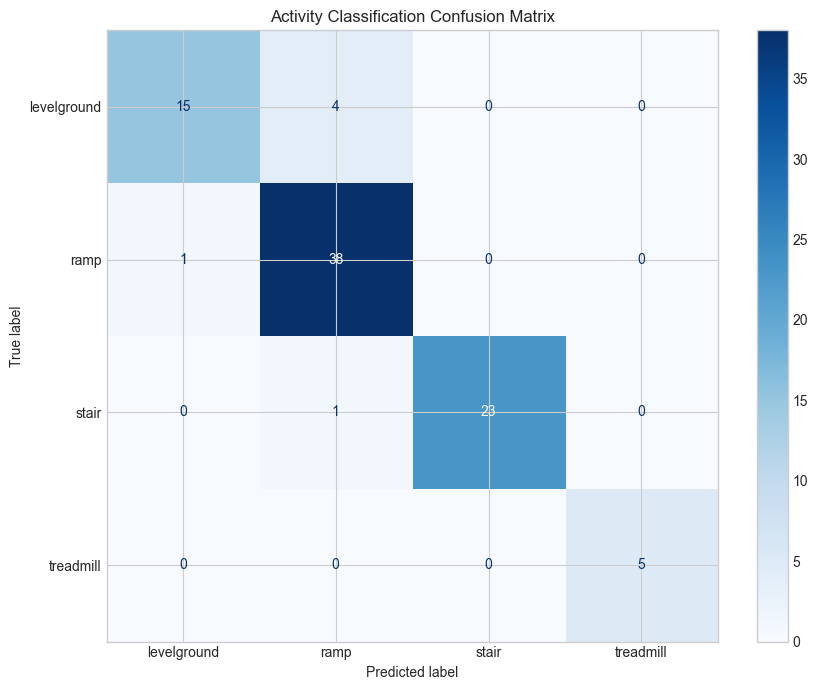

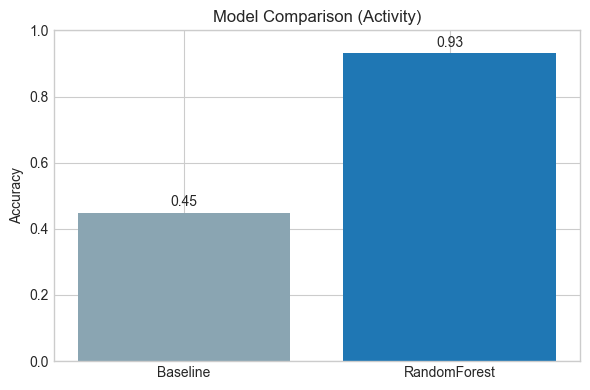

Cross-validation accuracy: mean=0.935, std=0.012


In [11]:
# Classification report and confusion matrix (activity)
if activity_eval.get("use_validation"):
    y_val = activity_eval["y_val"]
    y_pred = activity_eval["y_pred"]
    print("Classification report (activity):")
    print(classification_report(y_val, y_pred))

    fig, ax = plt.subplots(figsize=(9, 7))
    labels_sorted = sorted(activity_counts.keys())
    cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Activity Classification Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Validation skipped; no confusion matrix available.")

# Model comparison bar chart (baseline vs RandomForest)
if activity_eval.get("use_validation") and baseline_accuracy is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    model_names = ["Baseline", "RandomForest"]
    scores = [baseline_accuracy, activity_accuracy]
    ax.bar(model_names, scores, color=["#8aa5b2", "#1f77b4"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Model Comparison (Activity)")
    for i, score in enumerate(scores):
        ax.text(i, score + 0.02, f"{score:.2f}", ha="center")
    plt.tight_layout()
    plt.show()

if cv_scores is not None:
    print(f"Cross-validation accuracy: mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}")


FEATURE RELATIONSHIPS


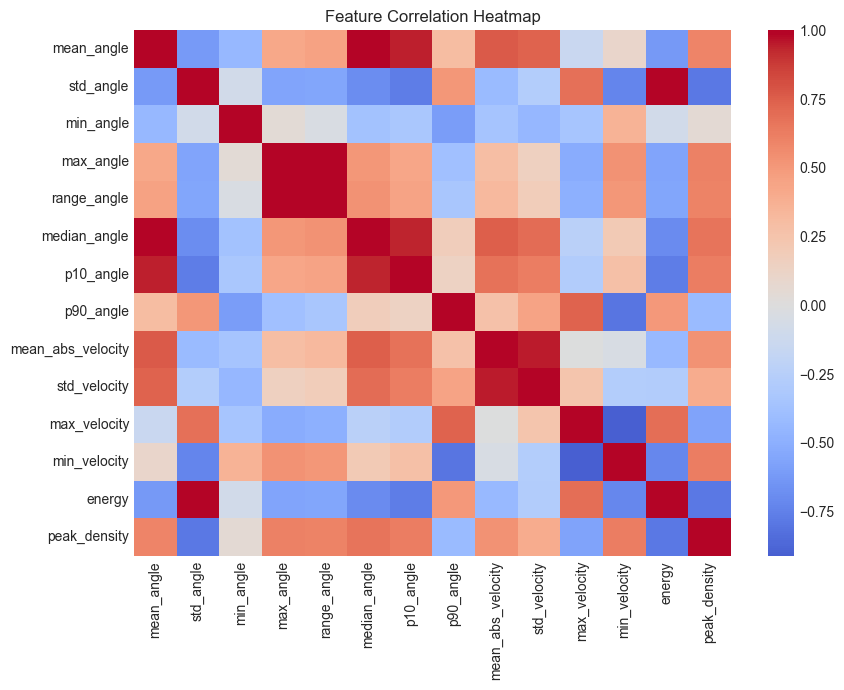

In [12]:
print_section("FEATURE RELATIONSHIPS")

# Feature correlation heatmap
corr = np.corrcoef(X, rowvar=False)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    xticklabels=FEATURE_NAMES,
    yticklabels=FEATURE_NAMES,
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



FEATURE IMPORTANCE AND LABEL DISTRIBUTION


Text(0.5, 1.0, 'RandomForest Feature Importance')

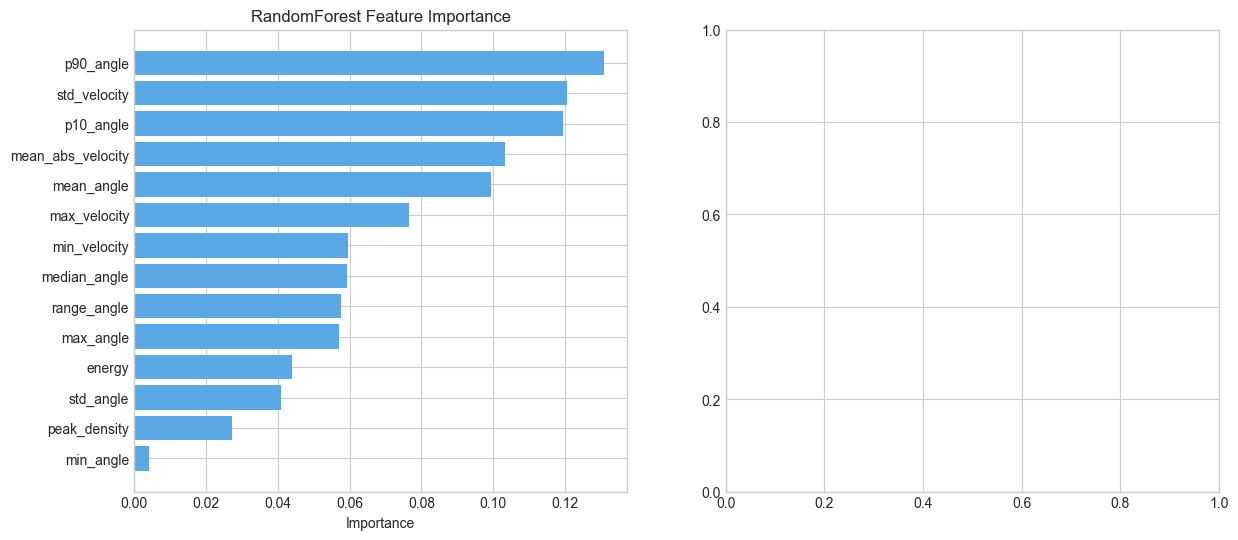

In [13]:
print_section("FEATURE IMPORTANCE AND LABEL DISTRIBUTION")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importance
importance = activity_clf.feature_importances_
indices = np.argsort(importance)[::-1]
axes[0].barh(range(len(FEATURE_NAMES)), importance[indices], color="#5aa9e6")
axes[0].set_yticks(range(len(FEATURE_NAMES)))
axes[0].set_yticklabels([FEATURE_NAMES[i] for i in indices])
axes[0].invert_yaxis()
axes[0].set_xlabel("Importance")
axes[0].set_title("RandomForest Feature Importance")



DISTRIBUTIONS


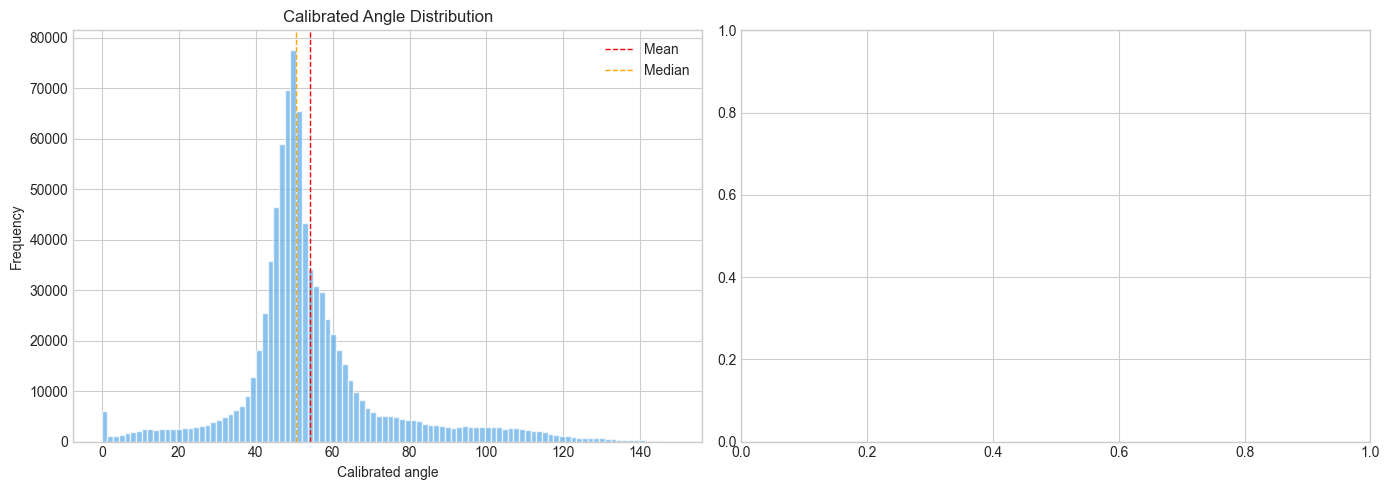

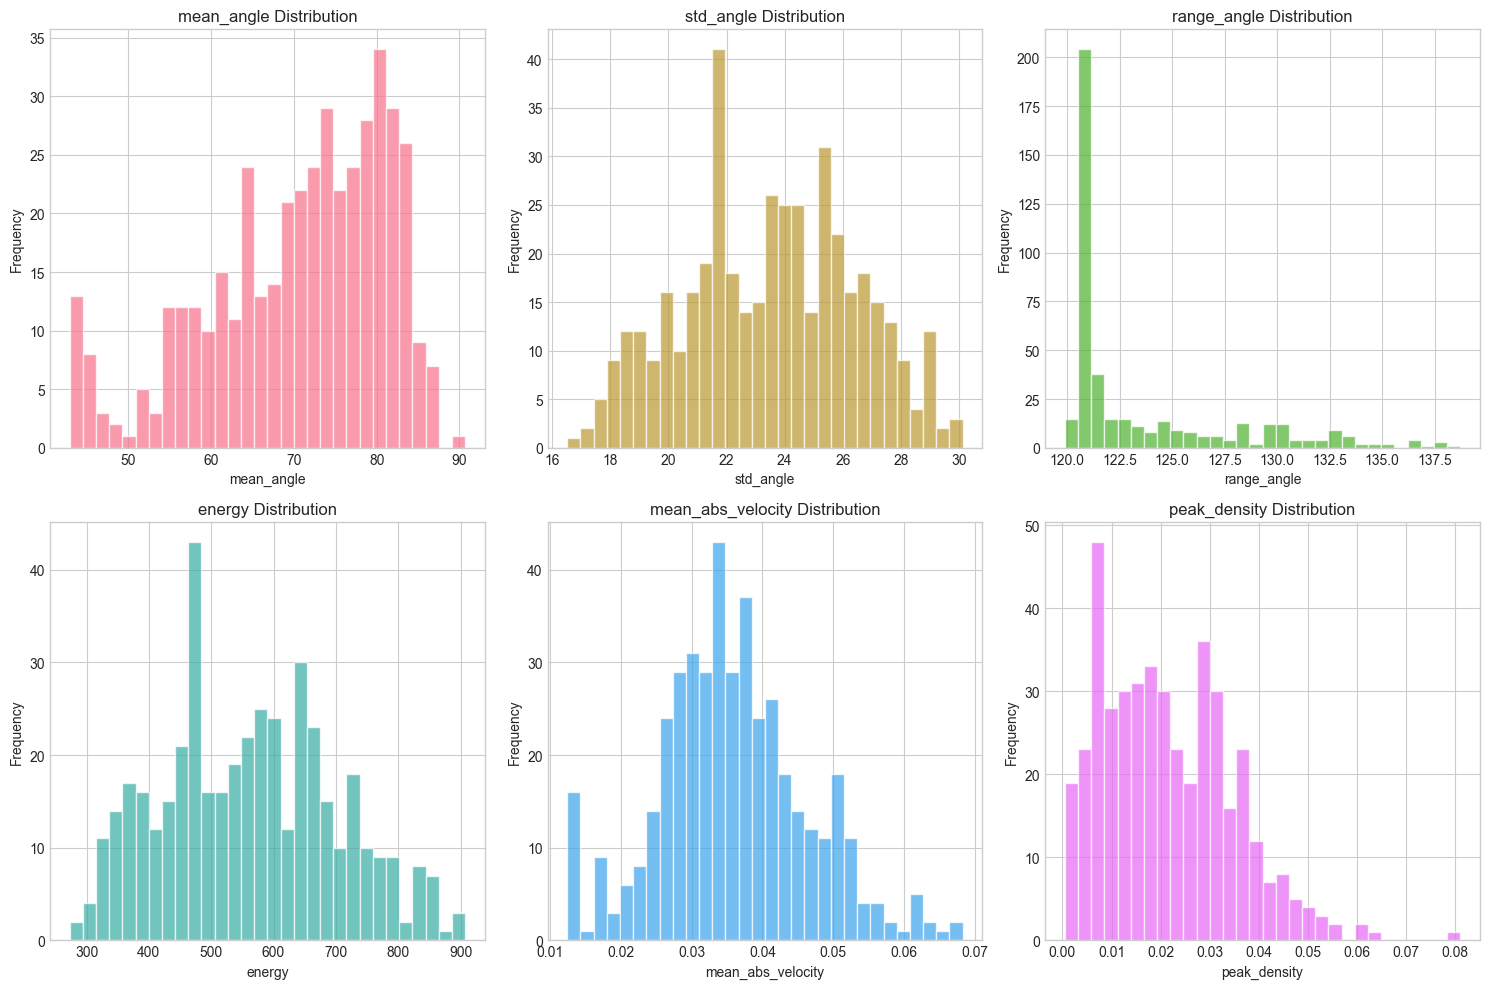

In [14]:
print_section("DISTRIBUTIONS")

# Calibration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(calibrated_angles, bins=100, color="#5aa9e6", alpha=0.7, edgecolor="white")
axes[0].axvline(np.mean(calibrated_angles), color="red", linestyle="--", linewidth=1, label="Mean")
axes[0].axvline(np.median(calibrated_angles), color="orange", linestyle="--", linewidth=1, label="Median")
axes[0].set_xlabel("Calibrated angle")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Calibrated Angle Distribution")
axes[0].legend()



plt.tight_layout()
plt.show()

# Feature distributions
key_features = ["mean_angle", "std_angle", "range_angle", "energy", "mean_abs_velocity", "peak_density"]
key_indices = [FEATURE_NAMES.index(f) for f in key_features if f in FEATURE_NAMES]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feat_idx in enumerate(key_indices):
    feature_col = X[:, feat_idx]
    axes[i].hist(feature_col, bins=30, color=sns.color_palette("husl", 6)[i], alpha=0.7, edgecolor="white")
    axes[i].set_xlabel(FEATURE_NAMES[feat_idx])
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"{FEATURE_NAMES[feat_idx]} Distribution")

plt.tight_layout()
plt.show()


## 10. Save Model Artifacts
This section saves the trained models and metadata for production use.

In [15]:
print_section("SECTION 10: SAVE MODEL ARTIFACTS")

artifact = {
    "model": anomaly_model,
    "scaler": scaler,
    "activity_classifier": activity_clf,
    "intention_classifier": intention_clf,
    "feature_names": FEATURE_NAMES,
    "angle_stats": {
        "mean": float(np.mean(calibrated_angles)),
        "std": float(np.std(calibrated_angles)),
        "median": float(np.median(calibrated_angles)),
        "p01": float(np.percentile(calibrated_angles, 1)),
        "p99": float(np.percentile(calibrated_angles, 99)),
    },
    "score_stats": {
        "p01": float(score_stats["p01"]),
        "p05": float(score_stats["p05"]),
        "p50": float(score_stats["p50"]),
    },
    "meta": {
        "source": str(DATA_ROOT),
        "source_subjects": [s.name for s in subject_roots],
        "subject_count": len(subject_roots),
        "sample_count": int(calibrated_angles.size),
        "window_count": len(activity_labels),
        "model_type": "IsolationForest",
        "data_decoder": "function_workspace_f64_fallback",
        "supports_activity_classification": activity_clf is not None,
        "supports_intention_classification": intention_clf is not None,
        "activity_label_counts": dict(sorted(activity_counts.items())),
        "intention_label_counts": dict(sorted(intention_counts.items())),
        "val_accuracy": activity_accuracy,
        "baseline_accuracy": baseline_accuracy,
        "cv_accuracy_mean": float(cv_scores.mean()) if cv_scores is not None else None,
        "cv_accuracy_std": float(cv_scores.std()) if cv_scores is not None else None,
        "velocity_normalized": True,
    },
}

joblib.dump(artifact, OUTPUT_MODEL)
print(f"Saved model: {OUTPUT_MODEL}")

metadata = artifact["meta"] | artifact["angle_stats"] | artifact["score_stats"]
with open(OUTPUT_META, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved metadata: {OUTPUT_META}")


SECTION 10: SAVE MODEL ARTIFACTS


Saved model: C:\mahmoud\college\backend\models\gait_model.joblib
Saved metadata: C:\mahmoud\college\backend\models\gait_model_meta.json


## 11. Inference Demo

In [16]:
print_section("SECTION 11: INFERENCE DEMO")

loaded_artifact = joblib.load(OUTPUT_MODEL)
print(f"Loaded model: {OUTPUT_MODEL.name}")

# test_angles = [45.0, 47.0, 52.0, 58.0, 62.0, 65.0, 63.0, 60.0, 55.0, 50.0]
test_angles = [100, 60,10,40,-29,90,150,2,78,7,8,2]
angle = test_angles[-1]

scaler = loaded_artifact["scaler"]
model = loaded_artifact["model"]
score_stats = loaded_artifact["score_stats"]

X_demo = np.array([[float(angle)]])
X_scaled = scaler.transform(X_demo)
pred = int(model.predict(X_scaled)[0])
score = float(model.decision_function(X_scaled)[0])

floor = score_stats["p01"]
threshold = score_stats["p05"]
denom = max(threshold - floor, 1e-6)
anomaly_strength = float(np.clip((threshold - score) / denom, 0.0, 1.0))

if pred == -1:
    classification = "Compensating (bad) step"
    assistance = float(np.clip(20.0 + 70.0 * anomaly_strength, 20.0, 95.0))
else:
    classification = "Good step"
    assistance = 0.0

print(f"Test angle: {angle:.1f}")
print(f"Model score: {score:.4f}")
print(f"Anomaly strength: {anomaly_strength:.4f}")
print(f"Classification: {classification}")
print(f"Assistance: {assistance:.1f}%")

activity_clf = loaded_artifact["activity_classifier"]
intention_clf = loaded_artifact["intention_classifier"]

if activity_clf:
    features = extract_window_features(np.array(test_angles)).reshape(1, -1)
    activity = activity_clf.predict(features)[0]
    intention = intention_clf.predict(features)[0]
    print(f"Activity: {activity}")
    print(f"Intention: {intention}")


SECTION 11: INFERENCE DEMO
Loaded model: gait_model.joblib
Test angle: 2.0
Model score: -0.1123
Anomaly strength: 0.9929
Classification: Compensating (bad) step
Assistance: 89.5%
Activity: levelground
Intention: ramp_up


## 12. Training Summary

In [17]:
val_text = f"{activity_accuracy:.1%}" if activity_accuracy is not None else "n/a"
intent_text = f"{intention_accuracy:.1%}" if intention_accuracy is not None else "n/a"
baseline_text = f"{baseline_accuracy:.1%}" if baseline_accuracy is not None else "n/a"
cv_text = (
    f"{cv_scores.mean():.3f} +/- {cv_scores.std():.3f}" if cv_scores is not None else "n/a"
)

print("\n")
print_section("TRAINING SUMMARY")
print("CONFIGURATION")
print(f"  Dataset root:   {DATA_ROOT}")
print(f"  Subjects:       {[s.name for s in subject_roots]}")
print(f"  Output model:   {OUTPUT_MODEL}")
print("\nDATA STATISTICS")
print(f"  Raw samples:     {calibrated_angles.size:>10,}")
print(f"  Windows:         {len(activity_labels):>10,}")
print(f"  Feature dims:    {len(FEATURE_NAMES):>10}")

print("\nMODEL PERFORMANCE")
print("  Anomaly detector: IsolationForest (n_estimators=300)")
print("  Activity classifier: RandomForest (n_estimators=350)")
print("  Intention classifier: RandomForest (n_estimators=350)")
print(f"  Validation accuracy (activity): {val_text}")
print(f"  Validation accuracy (intention): {intent_text}")
print(f"  Baseline accuracy (activity): {baseline_text}")
print(f"  Cross-validation (activity): {cv_text}")

print("\nCALIBRATION STATS")
print(f"  Mean angle:      {np.mean(calibrated_angles):.2f}")
print(f"  Std angle:       {np.std(calibrated_angles):.2f}")
print(f"  p01 angle:       {np.percentile(calibrated_angles, 1):.2f}")
print(f"  p99 angle:       {np.percentile(calibrated_angles, 99):.2f}")

print("\nLABEL DISTRIBUTION")
for label, count in sorted(activity_counts.items()):
    print(f"  {label:12s}: {count:4d} ({100 * count / len(activity_labels):5.1f}%)")

print("\nSAVED ARTIFACTS")
print(f"  Model:   {OUTPUT_MODEL}")
print(f"  Meta:    {OUTPUT_META}")





TRAINING SUMMARY
CONFIGURATION
  Dataset root:   C:\mahmoud\college
  Subjects:       ['AB06', 'AB07', 'AB08']
  Output model:   C:\mahmoud\college\backend\models\gait_model.joblib

DATA STATISTICS
  Raw samples:        868,000
  Windows:                434
  Feature dims:            14

MODEL PERFORMANCE
  Anomaly detector: IsolationForest (n_estimators=300)
  Activity classifier: RandomForest (n_estimators=350)
  Intention classifier: RandomForest (n_estimators=350)
  Validation accuracy (activity): 93.1%
  Validation accuracy (intention): 95.4%
  Baseline accuracy (activity): 44.8%
  Cross-validation (activity): 0.935 +/- 0.012

CALIBRATION STATS
  Mean angle:      54.16
  Std angle:       19.65
  p01 angle:       5.00
  p99 angle:       120.00

LABEL DISTRIBUTION
  levelground :   97 ( 22.4%)
  ramp        :  193 ( 44.5%)
  stair       :  120 ( 27.6%)
  treadmill   :   24 (  5.5%)

SAVED ARTIFACTS
  Model:   C:\mahmoud\college\backend\models\gait_model.joblib
  Meta:    C:\mahmo